# Task 5: Optimal Number of Retrieved Chunks (m)

Using the optimal model and reranker from Task 4, sweep m = 1, 2, 3, 5, 7, 10 to find the optimal number of retrieved context chunks.

In [1]:
import sys
sys.path.insert(0, '..')
sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from openai import OpenAI
import time

from eval_utils import load_questions, build_chunks, embed_chunks
from textwave.modules.extraction.embedding import Embedding
from textwave.modules.retrieval.index.bruteforce import BruteForceIndex
from textwave.modules.retrieval.reranker import Reranker
from textwave.modules.utils.metrics import Matching

questions = load_questions(deduplicate=True)
embedder = Embedding('all-MiniLM-L6-v2')
matcher = Matching()

# Use best strategy & best model & best reranker from Tasks 1-4
BEST_MODEL = 'qwen2.5:1.5b'
BEST_RERANKER = 'cross_encoder' 
M_VALUES = [1, 2, 3, 5, 7, 10]
MAX_RETRIEVE = max(M_VALUES) * 2

import os
os.makedirs('figures', exist_ok=True)

print('Building index...')
chunks, source_files = build_chunks(strategy='sentence', num_sentences=3, overlap_size=1)
embeddings = embed_chunks(chunks)
dim = embeddings.shape[1]
idx = BruteForceIndex(dim)
idx.add(embeddings, chunks)
print(f'Index ready: {idx.ntotal} chunks!')

/opt/anaconda3/envs/textwave311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5891.76it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using device: cpu


Loading weights: 100%|██████████| 393/393 [00:00<00:00, 5332.16it/s]


Building index...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 11582.44it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Index ready: 17161 chunks!


In [2]:
class QAGeneratorRAG:
    def __init__(self, model: str, temperature: float = 0.3):
        self.model = model
        self.client = OpenAI(api_key='ollama', base_url='http://localhost:11434/v1')
        self.temperature = temperature

    def generate_answer(self, query: str, context: list) -> str:
        combined = f"Question: {query}\n\nContext: {', '.join(context)}"
        response = self.client.chat.completions.create(
            model=self.model,
            temperature=self.temperature,
            max_tokens=120,
            messages=[
                {
                    'role': 'system',
                    'content': (
                        'You must answer the user questions only based on the provided context. '
                        'Do not use any external or prior knowledge. '
                        'Provide clear, concise, and full-sentence answers. '
                        'If the context does not mention the answer, respond with "No context".'
                    ),
                },
                {'role': 'user', 'content': combined},
            ],
        )
        time.sleep(1)
        return response.choices[0].message.content.strip()


generator = QAGeneratorRAG(model=BEST_MODEL)
reranker = Reranker(type=BEST_RERANKER)
print('Ready!')

Loading weights: 100%|██████████| 41/41 [00:00<00:00, 7487.55it/s]
BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-TinyBERT-L-2-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready!


In [3]:
# Sweep m values
m_sweep_results = {}

for m in M_VALUES:
    print(f'\nEvaluating m={m}...')
    rows = []
    grouped = questions.groupby('Question')

    for question, group in grouped:
        references = group['Answer'].tolist()
        difficulty = group['DifficultyFromAnswerer'].iloc[0]

        query_vec = embedder.encode(question)
        cand_chunks, cand_indices, _ = idx.search_with_indices(query_vec, MAX_RETRIEVE)

        # Rerank and take top m
        try:
            if BEST_RERANKER == 'sequential':
                ranked_docs, _, _ = reranker.rerank(
                    question, cand_chunks, seq_k1=MAX_RETRIEVE // 2, seq_k2=m
                )
            else:
                ranked_docs, _, _ = reranker.rerank(question, cand_chunks)
            context = ranked_docs[:m]
        except Exception as e:
            print(f'  Reranker error: {e}')
            context = cand_chunks[:m]

        try:
            answer = generator.generate_answer(query=question, context=context)
            em = matcher.exact_match(answer, references[0])
            scores, tm = matcher.transformer_match(answer, references[0], question)
            try:
                t_score = float(max(scores.values())) if scores else 0.0
            except (TypeError, ValueError, AttributeError):
                t_score = 0.0
        except Exception as e:
            answer, em, tm, t_score = '', 0, 0, 0.0
            print(f'  Generation error: {e}')

        rows.append({
            'question': question,
            'difficulty': difficulty,
            'm': m,
            'exact_match': int(em),
            'transformer_match': int(tm),
            'transformer_score': float(t_score) if not isinstance(t_score, dict) else 0.0,
        })

    m_sweep_results[m] = pd.DataFrame(rows)
    overall = m_sweep_results[m]['transformer_match'].mean()
    print(f'  m={m}: TM={overall:.4f}')
    m_sweep_results[m].to_csv(f'results_task5_m{m}.csv', index=False)

print('\nSweep complete!')


Evaluating m=1...
  Generation error: object of type 'float' has no len()
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: object of type 'float' has no len()
  Generation error: object of type 'float' has no len()
  Generation error: object of type 'float' has no len()
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: object of type 'float' has no len()
  Generation error: object of type 'float' has no len()
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: object of type 'float' has no len()
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: object of type 'float' has no len()
  Generation error: RobertaTokenizer has no attribute encode_plus
  Generation error: object of type 'float' has no len()
  Generation er

In [4]:
# Summary table
rows = []
for m, df in m_sweep_results.items():
    rows.append({
        'm': m,
        'Overall TM': df['transformer_match'].mean(),
        'Easy TM': df[df['difficulty'] == 'easy']['transformer_match'].mean(),
        'Medium TM': df[df['difficulty'] == 'medium']['transformer_match'].mean(),
        'Hard TM': df[df['difficulty'] == 'hard']['transformer_match'].mean(),
    })
m_summary = pd.DataFrame(rows)
print('\nTable: Performance vs Number of Retrieved Chunks (m)')
print(m_summary.to_string(index=False))

best_m = m_summary.loc[m_summary['Overall TM'].idxmax(), 'm']
print(f'\nOptimal m = {best_m}')


Table: Performance vs Number of Retrieved Chunks (m)
 m  Overall TM  Easy TM  Medium TM  Hard TM
 1    0.438596 0.724299   0.505747 0.305263
 2    0.460925 0.747664   0.528736 0.368421
 3    0.478469 0.775701   0.545977 0.378947
 5    0.465710 0.747664   0.557471 0.347368
 7    0.478469 0.757009   0.557471 0.400000
10    0.470494 0.766355   0.540230 0.357895

Optimal m = 3


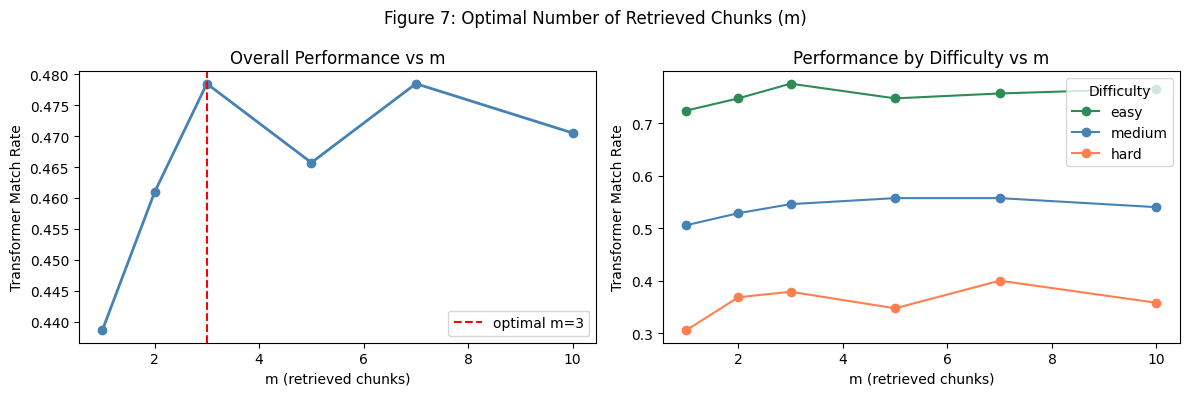

In [5]:
# Figure: performance vs m
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(m_summary['m'], m_summary['Overall TM'], 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_m, color='red', linestyle='--', label=f'optimal m={best_m}')
axes[0].set_xlabel('m (retrieved chunks)')
axes[0].set_ylabel('Transformer Match Rate')
axes[0].set_title('Overall Performance vs m')
axes[0].legend()

diffs = ['easy', 'medium', 'hard']
colors = ['seagreen', 'steelblue', 'coral']
for diff, color in zip(diffs, colors):
    scores = [
        m_sweep_results[m][m_sweep_results[m]['difficulty'] == diff]['transformer_match'].mean()
        for m in M_VALUES
    ]
    axes[1].plot(M_VALUES, scores, 'o-', label=diff, color=color)
axes[1].set_xlabel('m (retrieved chunks)')
axes[1].set_ylabel('Transformer Match Rate')
axes[1].set_title('Performance by Difficulty vs m')
axes[1].legend(title='Difficulty')

plt.suptitle('Figure 7: Optimal Number of Retrieved Chunks (m)')
plt.tight_layout()
plt.savefig('figures/task5_m_sweep.png', dpi=150)
plt.show()